# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.dgp import DataGenerationProcess, MNLAssortment
from core.variables import *
from core.structural import * 

# DGP

In [5]:
dgp_params = {
    'prod_fe_vars': [PointMass(1 + i * 0.05) for i in range(10)], 
    'dgp_seed': 0
}

dgp = MNLAssortment(**dgp_params)

In [6]:
purchase_records = dgp.sample(1000, seed=None)

# Estimation

In [7]:
emp_effects_arr = estimate_fixed_effects(purchase_records, dgp.n_products)

# Optimization

In [8]:
assortment, val_est = optimize(emp_effects_arr, int(dgp.n_products / 2))

# Evaluation

In [9]:
val_est = obj_func(emp_effects_arr, assortment)
val_true = obj_func(dgp.prod_fixed_effects, assortment)

result_df = pd.DataFrame({
    'Top-k Assortment': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Top-k Assortment
Estimated Policy Value,0.949739
True Policy Value,0.948980
Winner's Curse,0.000759


In [10]:
del val_est, val_true, result_df, assortment, emp_effects_arr, purchase_records, dgp

# Winner's Curse

In [11]:
dgp_params = {
    'prod_fe_vars': [PointMass(-0.05 + i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {}

In [12]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True,
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    3.4s finished


In [13]:
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_avg = wc_measures_dict[f'{optimizer}_nc_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer}_nc_wc_se']

    val_true_avg = wc_measures_dict[f'{optimizer}_nc_val_true_avg']
    val_true_se = wc_measures_dict[f'{optimizer}_nc_val_true_se']
    val_est_avg = wc_measures_dict[f'{optimizer}_nc_val_est_avg']
    val_est_se = wc_measures_dict[f'{optimizer}_nc_val_est_se']

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Top 50%:
  - Average True Value: 0.8331 (0.0001)
  - Average Estimated Value: 0.8619 (0.0041)
  - Average Winner's Curse (%): 288.41% (40.81%)


# Estimating Winner's Curse

In [14]:
dgp = MNLAssortment(**dgp_params)
purchase_records = dgp.sample(data_params['sample_size'], seed=0)

In [15]:
emp_effects_arr = estimate_fixed_effects(purchase_records, dgp.n_products)

In [16]:
selection_dict, val_est_dict = sample_splitting_estimate(
    purchase_records=purchase_records, 
    emp_effects_arr=emp_effects_arr, 
    optimization_params=optimization_params, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products
)

In [17]:
val_est_dict

{'top-0.5': 0.8181811528248143}

## Standard Bootstrap

In [18]:
boot_wc_dstn_dict = get_wc_boot_dstn(
    purchase_records=purchase_records, 
    optimization_params=optimization_params, 
    n_bootstraps=500, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.2s finished


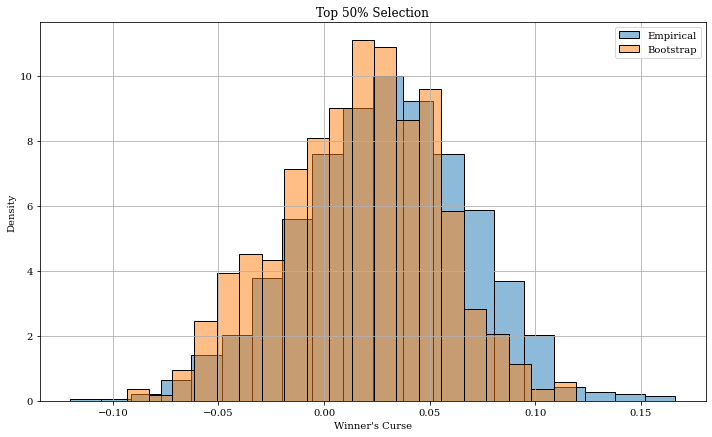

In [19]:
optimizer_name = 'top-0.5'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [20]:
boot_wc_dstn_dict = get_wc_m_out_of_n_boot_dstn(
    purchase_records=purchase_records, 
    optimization_params=optimization_params, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products, 
    n_bootstraps=500, 
    power=0.95, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.2s finished


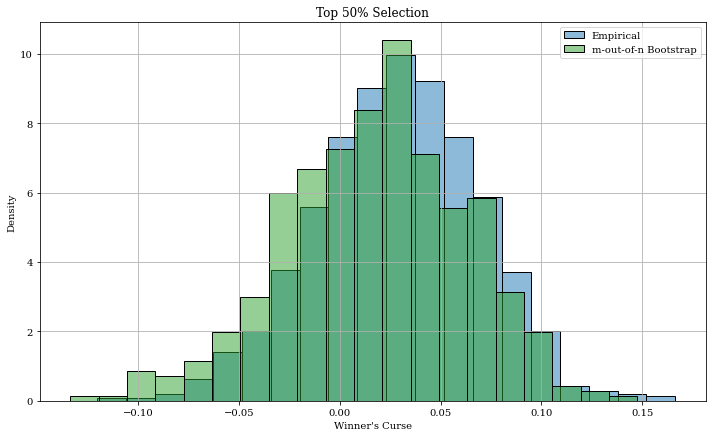

In [21]:
optimizer_name = 'top-0.5'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [22]:
boot_wc_dstn_dict = get_wc_num_boot_dstn(
    purchase_records=purchase_records, 
    optimization_params=optimization_params, 
    emp_fixed_effects=emp_effects_arr, 
    n_products=dgp.n_products, 
    power=-0.45, 
    n_bootstraps=500, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.2s finished


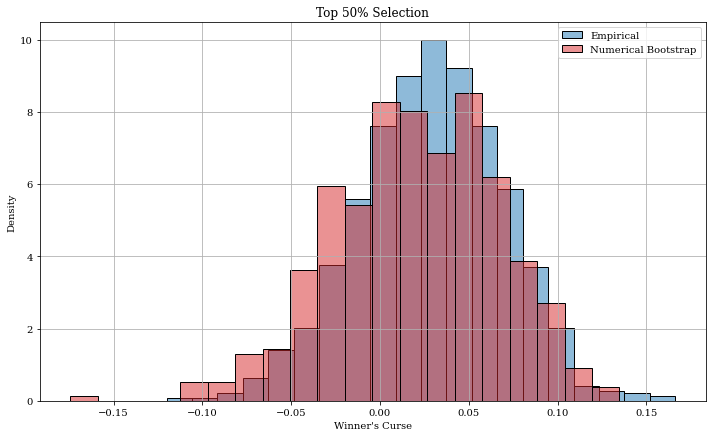

In [23]:
optimizer_name = 'top-0.5'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [24]:
del dgp, purchase_records, emp_effects_arr, boot_wc_dstn_dict

# Bias Correction

In [25]:
dgp_params = {
    'prod_fe_vars': [PointMass(i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
}

In [26]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True,
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.9s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:54: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   41.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   47.8s finished



Selection with Top 50%:
Policy Value: 
  - True Value: 0.8399 (0.0001)
  - No Correction: 0.8693 (0.0040)
  - Standard Bootstrap: 0.8530 (0.0045)
  - m-out-of-n Bootstrap: 0.8505 (0.0045)
  - Numerical Bootstrap: 0.8507 (0.0046)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 294.14% (39.57%)
  - Standard Bootstrap: 131.40% (44.79%)
  - m-out-of-n Bootstrap: 106.68% (45.33%)
  - Numerical Bootstrap: 108.58% (45.94%)
Median Winner's Curse: 
  - No Correction: 307.78% (39.57%)
  - Standard Bootstrap: 148.26% (44.79%)
  - m-out-of-n Bootstrap: 106.18% (45.33%)
  - Numerical Bootstrap: 128.31% (45.94%)

Sample Splitting: 
  - True Value: 0.8397 (0.0001)
  - Estimated Value: 0.8438 (0.0073)
  - Winner's Curse (%): 40.79% (73.44%)


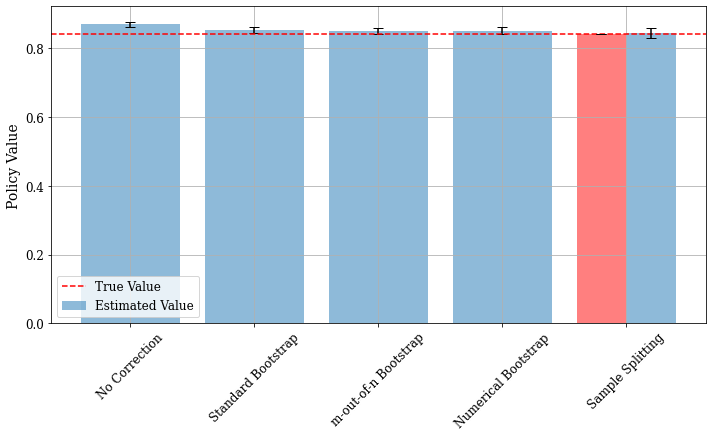

In [27]:
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

optimizer_key = 'top-0.5'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()]
    )
# ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


# Comparative Statics

## Delta tau

In [28]:
dgp_params = {
    'prod_fe_vars': [None] * 10, 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
}

In [29]:
base_effect = 0
delta_tau_list = [0.005, 0.01, 0.05, 0.1, 0.5]

delta_tau_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta Tau: {delta_tau}')

    dgp_params['prod_fe_vars'] = [PointMass(delta_tau * i) for i in range(10)]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    delta_tau_result_dict[delta_tau] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta Tau: 0.005
Running 500 experiments...


KeyboardInterrupt: 

In [ ]:
with open('results/mnl_assort_delta_tau.pkl', 'wb') as f:
    pickle.dump(delta_tau_result_dict, f)

NameError: name 'delta_tau_result_dict' is not defined

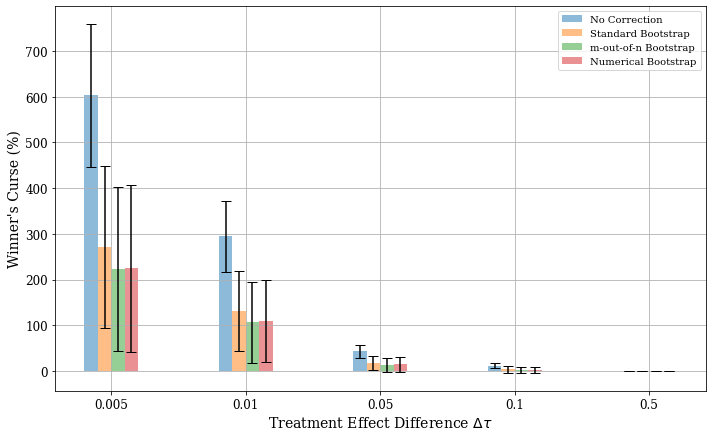

$\Delta\tau=0.005$  $\Delta\tau=0.01$  \
No Correction        Mean                602.87             294.14   
                     Median              628.02             307.78   
                     S.E.                 79.89              39.57   
Standard Bootstrap   Mean                272.01             131.40   
                     Median              289.79             148.26   
                     S.E.                 90.45              44.79   
m-out-of-n Bootstrap Mean                222.37             106.68   
                     Median              227.63             106.18   
                     S.E.                 91.52              45.33   
Numerical Bootstrap  Mean                224.27             108.58   
                     Median              268.17             128.31   
                     S.E.                 92.90              45.94   

                             $\Delta\tau=0.05$  $\Delta\tau=0.1$  \
No Correction        Mean                42.96             11.45   
                     Median              43.40             13.99   
                     S.E.                 7.18              3.06   
Standard Bootstrap   Mean                17.09              3.04   
                     Median              19.19              4.62   
                     S.E.                 8.07              3.38   
m-out-of-n Bootstrap Mean                13.05              1.39   
                     Median              16.20              2.49   
                     S.E.                 8.18              3.45   
Numerical Bootstrap  Mean                14.27              2.64   
                     Median              15.43              4.99   
                     S.E.                 8.31              3.48   

                             $\Delta\tau=0.5$  
No Correction        Mean               -0.07  
                     Median              0.95  
                     S.E.                0.15  
Standard Bootstrap   Mean               -0.09  
                     Median              0.95  
                     S.E.                0.15  
m-out-of-n Bootstrap Mean               -0.09  
                     Median              0.95  
                     S.E.                0.15  
Numerical Bootstrap  Mean                0.04  
                     Median              0.95  
                     S.E.                0.13

In [ ]:
# parameters
optimizer_key = 'top-0.5'
result_dict = delta_tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Capacity

In [ ]:
dgp_params = {
    'prod_fe_vars': [PointMass(i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': None}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
}

In [ ]:
capacity_list = [1, 2, 3, 4, 5, 6, 7, 8, 9]

capacity_result_dict = {capacity: None for capacity in capacity_list}

for capacity in capacity_list:
    print(f'\nCapacity: {capacity}')

    optimization_params['top-0.5']['params']['capacity'] = capacity

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    capacity_result_dict[capacity] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Capacity: 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    5.9s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:54: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   43.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   49.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Capacity: 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   36.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   42.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Capacity: 3
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   40.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   46.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Capacity: 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   39.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   46.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Capacity: 9
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.1s
/Users/iamsikun/Desktop/Research/winners-curse/core/structural.py:54: RuntimeWarning: overflow encountered in exp
  denom = 1 + np.sum(np.exp(params))
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   39.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   46.1s finished


In [ ]:
with open('results/mnl_assort_capacity.pkl', 'wb') as f:
    pickle.dump(capacity_result_dict, f)

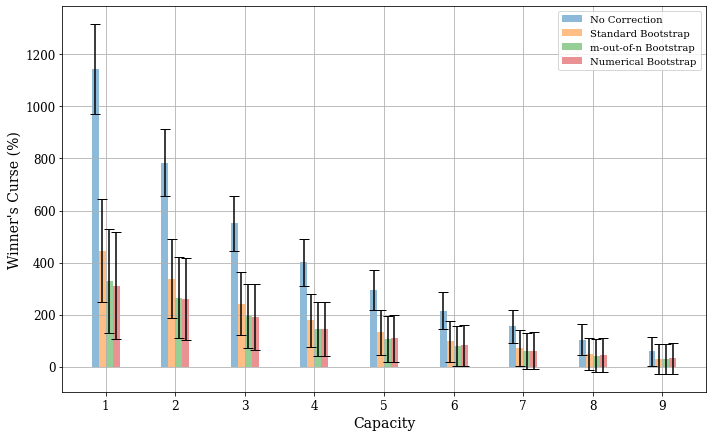

Capacity=1  Capacity=2  Capacity=3  Capacity=4  \
No Correction        Mean       1144.25      783.98      550.18      400.30   
                     Median     1088.70      776.41      558.20      417.40   
                     S.E.         88.19       66.21       53.52       45.29   
Standard Bootstrap   Mean        445.27      338.17      242.62      178.69   
                     Median      346.37      332.31      254.49      193.25   
                     S.E.        100.76       77.56       62.25       52.07   
m-out-of-n Bootstrap Mean        329.87      265.29      193.88      144.44   
                     Median      256.88      258.26      189.34      152.88   
                     S.E.        102.00       78.83       63.32       52.81   
Numerical Bootstrap  Mean        311.60      258.90      191.43      144.69   
                     Median      219.12      266.82      201.67      164.01   
                     S.E.        105.26       80.68       64.50       53.64   

                             Capacity=5  Capacity=6  Capacity=7  Capacity=8  \
No Correction        Mean        294.14      215.72      154.68      103.59   
                     Median      307.78      235.92      181.68      135.60   
                     S.E.         39.57       35.52       32.50       30.18   
Standard Bootstrap   Mean        131.40       96.82       70.79       48.75   
                     Median      148.26      106.00       79.12       61.87   
                     S.E.         44.79       39.49       35.42       32.21   
m-out-of-n Bootstrap Mean        106.68       79.65       58.99       41.87   
                     Median      106.18       81.40       63.45       54.51   
                     S.E.         45.33       39.82       35.59       32.21   
Numerical Bootstrap  Mean        108.58       81.98       61.99       45.09   
                     Median      128.31       97.34       82.22       66.93   
                     S.E.         45.94       40.31       35.97       32.54   

                             Capacity=9  
No Correction        Mean         59.20  
                     Median      101.60  
                     S.E.         28.33  
Standard Bootstrap   Mean         30.66  
                     Median       38.67  
                     S.E.         29.54  
m-out-of-n Bootstrap Mean         28.22  
                     Median       43.66  
                     S.E.         29.39  
Numerical Bootstrap  Mean         31.34  
                     Median       50.22  
                     S.E.         29.72

In [ ]:
# parameters
optimizer_key = 'top-0.5'
result_dict = capacity_result_dict.copy()
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for capacity in capacity_list:
    data[capacity] = {}

    data[capacity]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[capacity][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[capacity][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[capacity][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[capacity][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[capacity][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[capacity][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[capacity][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for capacity in capacity_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[capacity][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=['Capacity={}'.format(p) for p in capacity_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(capacity_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in capacity_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in capacity_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Capacity', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(capacity_list)), labels=capacity_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Sample Size

In [ ]:
dgp_params = {
    'prod_fe_vars': [PointMass(i * 0.01) for i in range(10)], 
    'dgp_seed': 0
}

optimization_params = {
    'top-0.5': {
        'optimizer': optimize, 
        'params': {'capacity': int(0.5 * len(dgp_params['prod_fe_vars']))}, 
        'display_name': 'Top 50%'
    }
}

data_params = {'sample_size': None}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
}

In [31]:
sample_size_list = [100, 500, 1000, 2500, 5000]

sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size: {sample_size}')

    data_params['sample_size'] = sample_size

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True,
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Sample Size: 100
Running 1 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    3.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 500
Running 1 experiments...


[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    1.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 1000
Running 1 experiments...


[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    1.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 2500
Running 1 experiments...


[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size: 5000
Running 1 experiments...


[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    1.9s finished


In [ ]:
with open('results/mnl_assort_sample_size.pkl', 'wb') as f:
    pickle.dump(sample_size_result_dict, f)

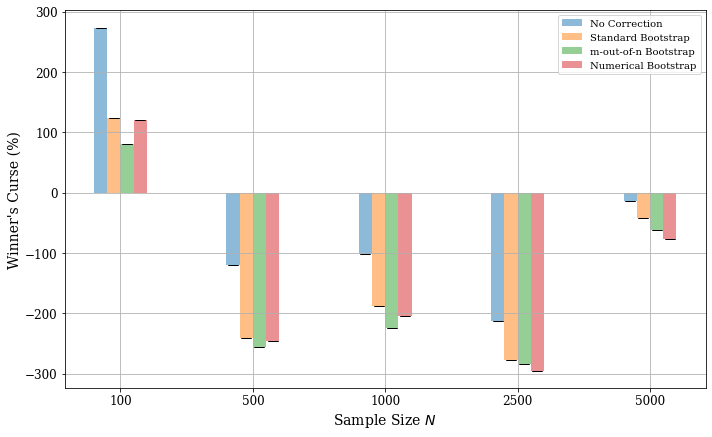

$N=100$  $N=500$  $N=1000$  $N=2500$  $N=5000$
No Correction        Mean     273.46  -120.59   -101.35   -213.51    -13.54
                     Median   273.46  -120.59   -101.35   -213.51    -13.54
                     S.E.       0.00     0.00      0.00      0.00      0.00
Standard Bootstrap   Mean     124.32  -241.01   -188.39   -277.22    -42.90
                     Median   124.32  -241.01   -188.39   -277.22    -42.90
                     S.E.       0.00     0.00      0.00      0.00      0.00
m-out-of-n Bootstrap Mean      80.98  -255.22   -225.01   -284.10    -62.24
                     Median    80.98  -255.22   -225.01   -284.10    -62.24
                     S.E.       0.00     0.00      0.00      0.00      0.00
Numerical Bootstrap  Mean     119.51  -246.72   -204.42   -295.06    -76.57
                     Median   119.51  -246.72   -204.42   -295.06    -76.57
                     S.E.       0.00     0.00      0.00      0.00      0.00

In [32]:
# parameters
optimizer_key = 'top-0.5'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['prod_fe_vars'][1].mean - dgp_params['prod_fe_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)